## Importando bibliotecas 

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Latex
import numpy as np

pd.set_option("display.max_columns", None)

In [147]:
df = pd.read_csv("../data/german_credit_data.csv", index_col = 0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


#### Leitura inicial

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


Há valores ausentes nas colunas "Saving accounts" e "Checking accounts".

In [149]:
missing_table = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Percentual (%)', ascending=False)

missing_table

,Valores Ausentes,Percentual (%)
Checking account,394,39.4
Saving accounts,183,18.3
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


In [150]:
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


In [151]:
# Mapeamento 
job_map = {
    '0': 'Não qualificado / Não residente',
    '1': 'Não qualificado / Residente',
    '2': 'Qualificado',
    '3': 'Altamente qualificado / Gestão'
}

df['Job'] = df['Job'].astype(str).map(job_map)

#### Explorando as Variáveis 
- Sexo (Sex): Masculino (male), Feminino (female)
  
-  Moradia (Housing): Casa Própria (own), Casa Cedida (free), Casa Alugada (rent)

-  Poupança (Saving accounts): Não Informado (nan), Saldo Baixo(little), Saldo Muito Alto (quite rich), Saldo Alto (rich), Saldo Médio (moderate)

-  Conta Corrente (Checking account): Saldo Baixo (little), Saldo Moderado (moderate), Não Informado (nan), Saldo Alto (rich)

-  Motivo (Purpose): Motivo (Rádio/TV), Educação (education), Móveis/Equipamentos (furniture/equipment), Carro (car), Negócios (business), Eletrodomésticos (domestic appliances), Reparos (repairs), Férias/Outro (vacation/others)

-  Risco (Risk): Bom Pagador (good), Mau Pagador (bad)

A partir da exploração acima:

As colunas "Saving accounts" (Contas de poupança) e "Checking accounts" (Contas correntes) são dados ordinais.

As colunas "Housing" (Moradia), "Sex" (Sexo), "Purpose" (Motivo) e "Risk" (Risco) são dados categóricos (nominais).

# EDA [ Análise exploratória dos dados ]

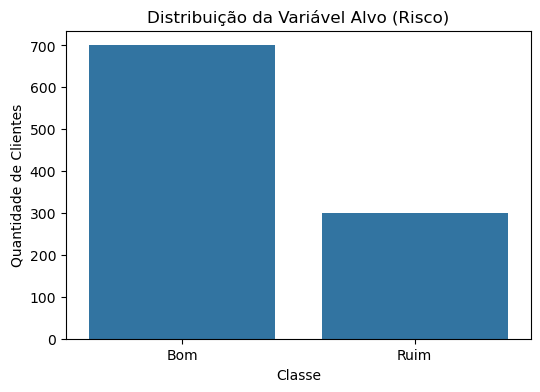

In [152]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Risk",
    order=["good", "bad"] 
)

plt.title("Distribuição da Variável Alvo (Risco)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Clientes")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Bom", "Ruim"])

plt.show()

#### Análise das variáveis numéricas

In [153]:
numeric_cols = ["Age", "Credit amount", "Duration"]

stats_summary = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
stats_summary['median'] = df[numeric_cols].median()
stats_summary['skewness'] = df[numeric_cols].skew()
stats_summary['kurtosis'] = df[numeric_cols].kurtosis()

stats_summary = stats_summary[[
    'count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness', 'kurtosis'
]].round(2)

stats_summary

,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
Age,1000.0,35.55,11.38,19.0,27.0,33.0,42.00,75.0,1.02,0.60
Credit amount,1000.0,3271.26,2822.74,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
Duration,1000.0,20.90,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92


Assimetria à Direita: Média > mediana e skewness > 1 em todas as variáveis numéricas.

Credit amount: Forte cauda longa e outliers (máx. 18.424 DM; curtose 4,29).

Age e Duration: Mediana de 33 anos e 18 meses de prazo contratual.

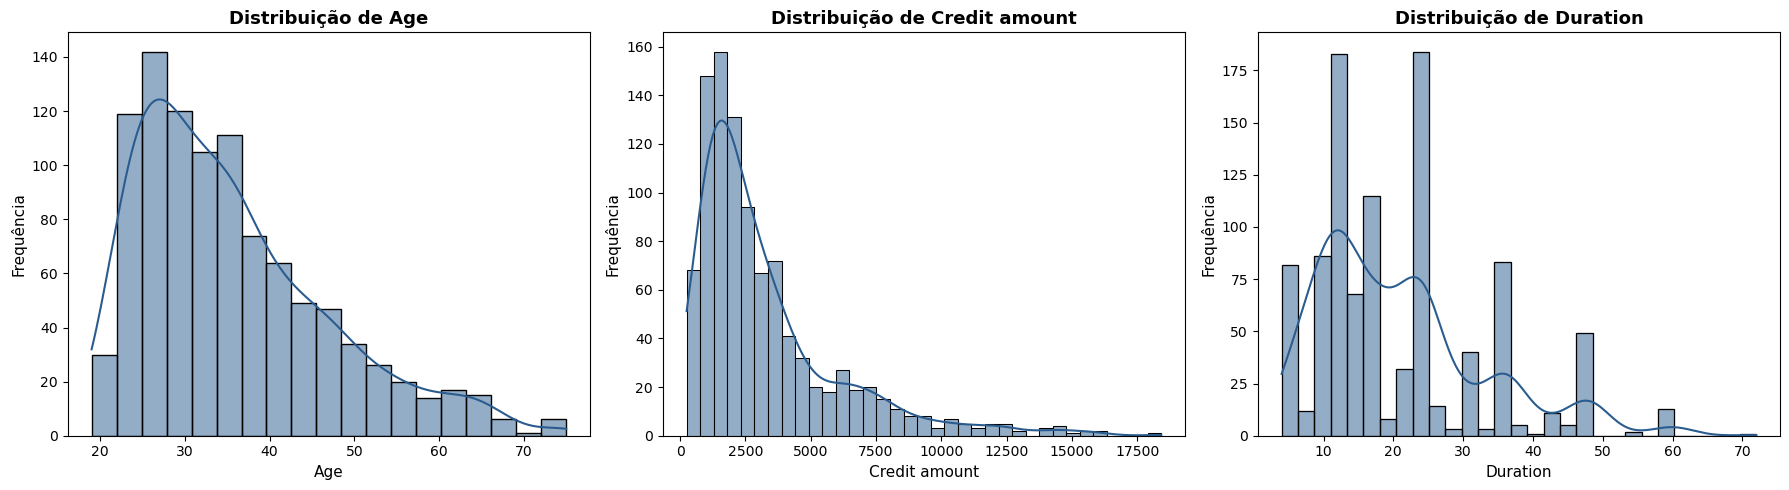

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="#2b5c8f",
        ax=axes[i]
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequência', fontsize=11)

plt.tight_layout()
plt.show()

O cliente padrão é jovem (25–35 anos), busca empréstimos de menor valor (< 5.000) e com prazos contratuais curtos/médios (12 a 24 meses)

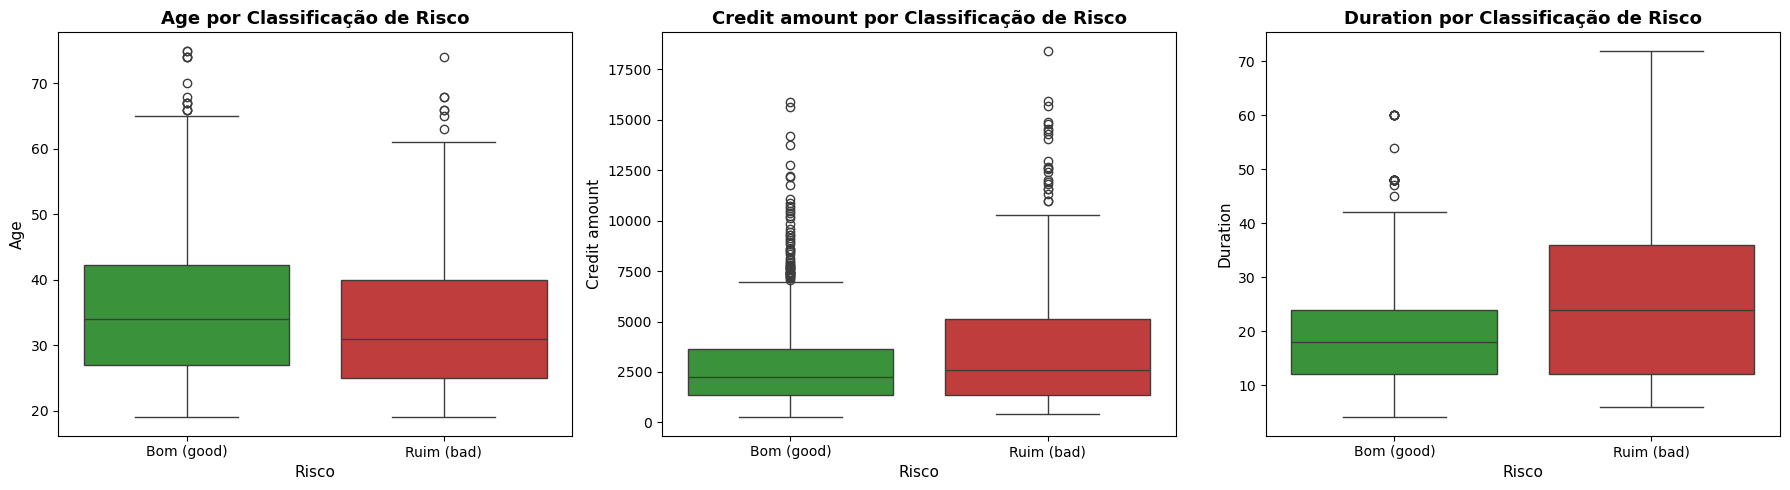

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x='Risk',
        y=col,
        hue='Risk',
        order=['good', 'bad'],
        palette={'good': '#2ca02c', 'bad': '#d62728'},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} por Classificação de Risco', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Risco', fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Bom (good)', 'Ruim (bad)'])
    axes[i].set_ylabel(col, fontsize=11)

plt.tight_layout()
plt.show()

Clientes inadimplentes concentram empréstimos de maior valor e prazos mais longos, agravando a severidade do prejuízo financeiro.

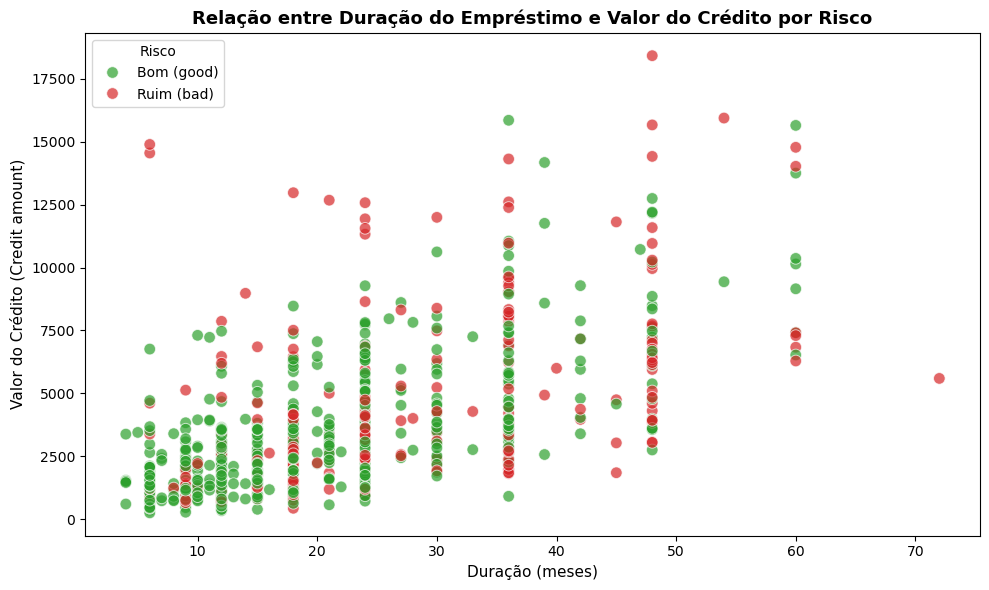

In [156]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x='Duration',
    y='Credit amount',
    hue='Risk',
    hue_order=['good', 'bad'],
    palette={'good': '#2ca02c', 'bad': '#d62728'},
    alpha=0.7,
    s=70
)

plt.title('Relação entre Duração do Empréstimo e Valor do Crédito por Risco', fontsize=13, fontweight='bold')
plt.xlabel('Duração (meses)', fontsize=11)
plt.ylabel('Valor do Crédito (Credit amount)', fontsize=11)

# Obtém os manipuladores originais com as cores corretas e renomeia apenas os textos
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Bom (good)', 'Ruim (bad)'], title='Risco', loc='upper left')

plt.tight_layout()
plt.show()

O risco de crédito é fortemente condicionado pela combinação de tempo de exposição e volume financeiro. Prazos longos ampliam a incerteza de pagamento.

#### Análise das variáveis categóricas

In [157]:
# Estatísticas das variáveis categóricas
df.describe(include="object")

,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,1000,817,606,1000,1000
unique,2,4,3,4,3,8,2
top,male,Qualificado,own,little,little,car,good
freq,690,630,713,603,274,337,700


- Há predominância masculina
- muitos clientes possuem casa própria.
- Boa parte dos empréstimos foi destinada à compra de veículos.

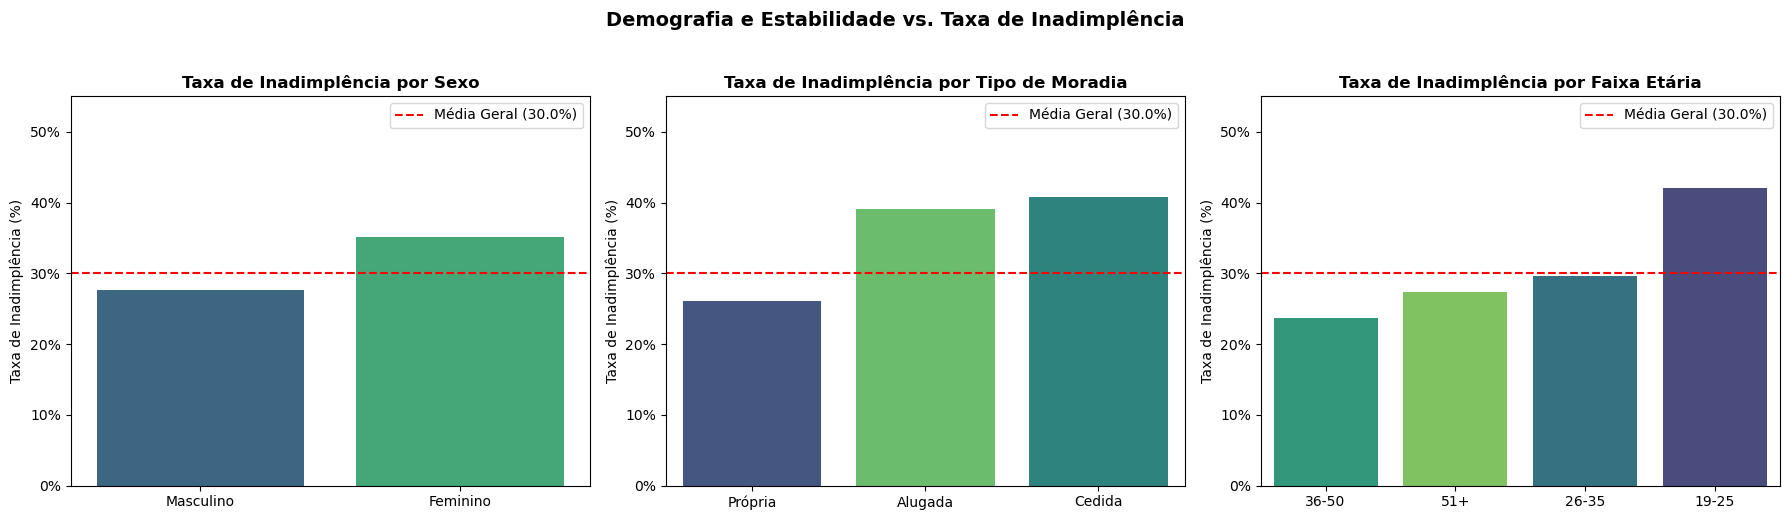

In [158]:
from matplotlib.ticker import PercentFormatter

df['Risco_Num'] = df['Risk'].map({'bad': 1, 'good': 0})

# faixas de idade para análise demográfica
df['Faixa_Idade'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 50, 75],
    labels=['19-25', '26-35', '36-50', '51+']
)

# Média geral de inadimplência da base (30%)
media_geral = df['Risco_Num'].mean()

#Demografia & Estabilidade (Sex, Housing, Faixa_Idade)
grid1_config = [
    {
        'col': 'Sex',
        'title': 'Sexo',
        'labels': {'female': 'Feminino', 'male': 'Masculino'},
        'rot': 0
    },
    {
        'col': 'Housing',
        'title': 'Tipo de Moradia',
        'labels': {'own': 'Própria', 'rent': 'Alugada', 'free': 'Cedida'},
        'rot': 0
    },
    {
        'col': 'Faixa_Idade',
        'title': 'Faixa Etária',
        'labels': None,
        'rot': 0
    }
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, conf in enumerate(grid1_config):
    col = conf['col']
    ax = axes[i]
    
    order = df.groupby(col, observed=False)['Risco_Num'].mean().sort_values().index.tolist()
    
    sns.barplot(
        data=df,
        x=col,
        y='Risco_Num',
        hue=col,
        order=order,
        palette='viridis',
        errorbar=None,
        legend=False,
        ax=ax
    )
    
    ax.axhline(media_geral, color='red', linestyle='--', linewidth=1.5, label=f'Média Geral ({media_geral:.1%})')
    
    ax.set_title(f'Taxa de Inadimplência por {conf["title"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 0.55)
    ax.legend(loc='upper right')
    
    ax.set_xticks(range(len(order)))
    if conf['labels']:
        ax.set_xticklabels([conf['labels'].get(v, str(v)) for v in order], rotation=conf['rot'])
    else:
        ax.set_xticklabels(order, rotation=conf['rot'])

plt.suptitle('Demografia e Estabilidade vs. Taxa de Inadimplência', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()



Sexo: Mulheres registram taxa de calote de ~35% vs. ~28% dos homens; embora haja maior inadimplência relativa no público feminino na base

Tipo de Moradia: Moradia Própria tem o menor índice de risco (~26%), enquanto Alugada (~39%) e Gratuita (~41%) disparam acima da média geral; a posse de patrimônio imobiliário atua como forte indicador de estabilidade financeira e solidez de garantias.

Faixa Etária: Jovens de 19–25 anos atingem a marca crítica de ~42% de inadimplência, caindo progressivamente com a maturidade (mínima de ~24% em 36–50 anos)

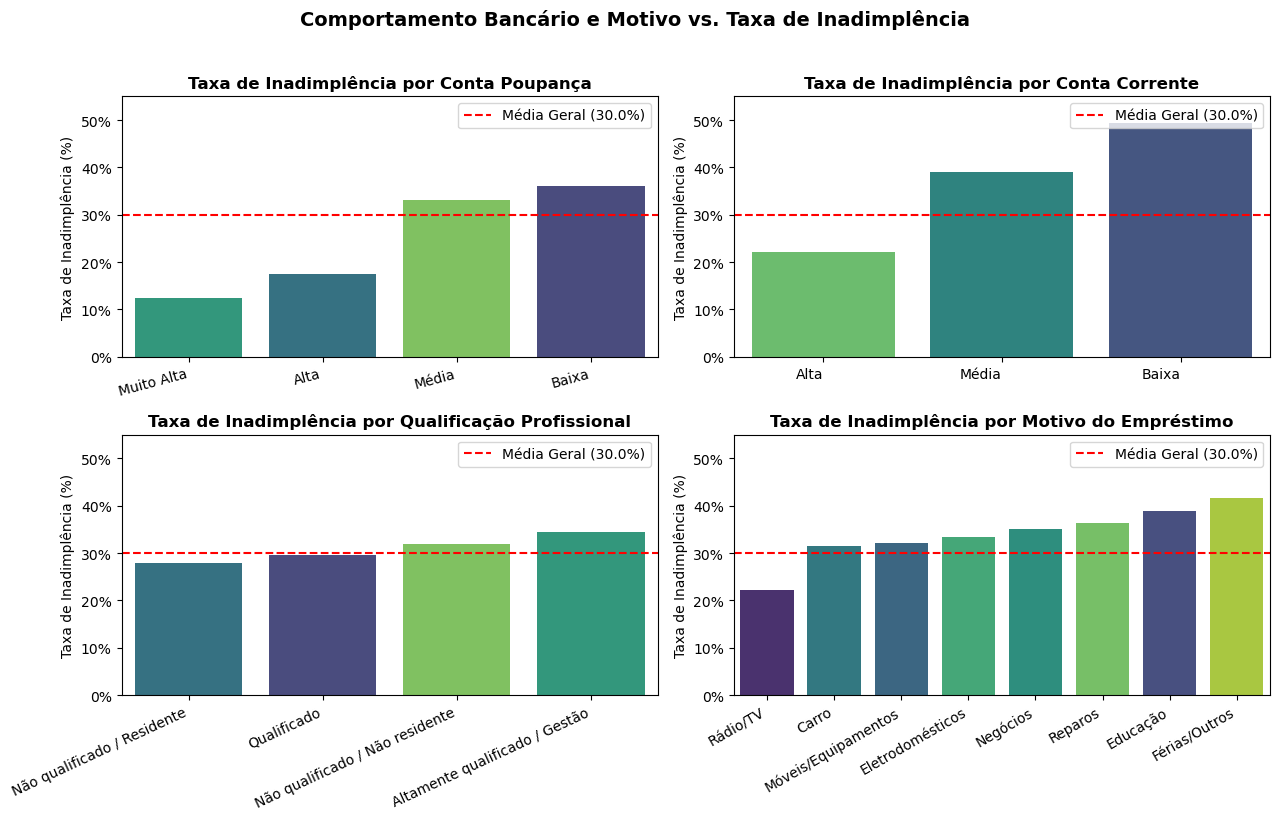

In [159]:
#Comportamento Bancário & Motivo (Saving, Checking, Job, Purpose)
grid2_config = [
    {
        'col': 'Saving accounts',
        'title': 'Conta Poupança',
        'labels': {'little': 'Baixa', 'moderate': 'Média', 'quite rich': 'Alta', 'rich': 'Muito Alta'},
        'rot': 15
    },
    {
        'col': 'Checking account',
        'title': 'Conta Corrente',
        'labels': {'little': 'Baixa', 'moderate': 'Média', 'rich': 'Alta'},
        'rot': 0
    },
    {
        'col': 'Job',
        'title': 'Qualificação Profissional',
        'labels': None,
        'rot': 25
    },
    {
        'col': 'Purpose',
        'title': 'Motivo do Empréstimo',
        'labels': {
            'radio/TV': 'Rádio/TV',
            'education': 'Educação',
            'furniture/equipment': 'Móveis/Equipamentos',
            'car': 'Carro',
            'business': 'Negócios',
            'domestic appliances': 'Eletrodomésticos',
            'repairs': 'Reparos',
            'vacation/others': 'Férias/Outros'
        },
        'rot': 30
    }
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, conf in enumerate(grid2_config):
    col = conf['col']
    ax = axes[i]
    
    order = df.groupby(col, observed=False)['Risco_Num'].mean().sort_values().index.tolist()
    
    sns.barplot(
        data=df,
        x=col,
        y='Risco_Num',
        hue=col,
        order=order,
        palette='viridis',
        errorbar=None,
        legend=False,
        ax=ax
    )
    
    ax.axhline(media_geral, color='red', linestyle='--', linewidth=1.5, label=f'Média Geral ({media_geral:.1%})')
    
    ax.set_title(f'Taxa de Inadimplência por {conf["title"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 0.55)
    ax.legend(loc='upper right')
    
    ax.set_xticks(range(len(order)))
    if conf['labels']:
        ax.set_xticklabels([conf['labels'].get(v, str(v)) for v in order], rotation=conf['rot'], ha='right')
    else:
        ax.set_xticklabels(order, rotation=conf['rot'], ha='right')

plt.suptitle('Comportamento Bancário e Motivo vs. Taxa de Inadimplência', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



- Conta Poupança (Saving accounts): A taxa de inadimplência tem relação inversamente proporcional ao saldo acumulado, variando de ~12% em "Muito Alta" para ~36% em "Baixa";

- Conta Corrente (Checking account): É a variável com maior poder discriminante do conjunto; clientes com saldo "Baixo" alcançam quase 50% de calote, enquanto saldo "Alto" reduz a taxa para ~22%; a liquidez imediata no curto prazo é o sinal de alerta mais direto sobre a saúde financeira do tomador.

- Qualificação Profissional (Job): Apresenta baixa variação em relação à média geral (oscilando entre ~28% para residentes não qualificados e ~34% para gestão/altamente qualificados); o nível de qualificação isolado não define solvência, indicando que a capacidade de pagamento real importa mais que o status formal do cargo.

- Motivo do Empréstimo (Purpose): O destino do crédito influencia diretamente o risco de calote: compras de bens duráveis como Rádio/TV têm a menor inadimplência (\~22%), enquanto destinos não patrimoniais ou de retorno financeiro postergado, como Educação (\~39%) e Férias/Outros (\~42%)  disparam acima da média geral, isso indica que créditos voltados ao consumo supérfluo ou com fluxos de caixa incertos exigem tetos de valor mais conservadores e critérios adicionais de concessão.

--- Cruzamento de Valores Ausentes em Checking Account vs. Risco ---


Risk,Total_Clientes,Bom Pagador (%),Mau Pagador (%)
Status_Conta_Corrente,,,
Não Possui Conta (NaN),394,88.32,11.68
Possui Conta Registrada,606,58.09,41.91


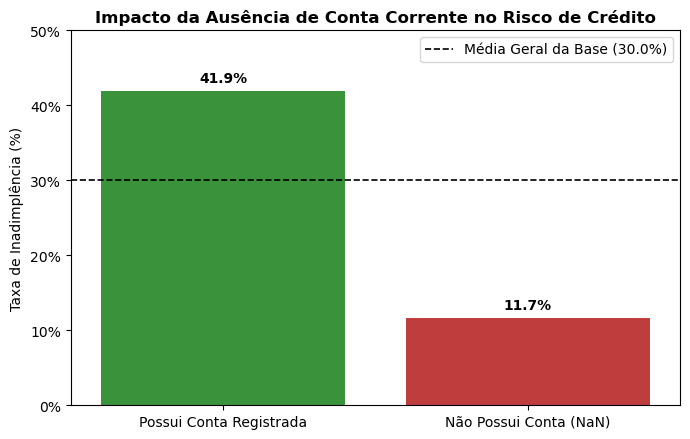

In [160]:
# Nulos: Checking account ausente vs. Risco
df['Status_Conta_Corrente'] = df['Checking account'].apply(
    lambda x: 'Não Possui Conta (NaN)' if pd.isnull(x) else 'Possui Conta Registrada'
)

# Tabela cruzada 
crosstab_nulos = pd.crosstab(
    df['Status_Conta_Corrente'],
    df['Risk'],
    normalize='index'
).mul(100).round(2)

crosstab_nulos['Total_Clientes'] = df['Status_Conta_Corrente'].value_counts()
crosstab_nulos = crosstab_nulos.rename(columns={'good': 'Bom Pagador (%)', 'bad': 'Mau Pagador (%)'})

print("--- Cruzamento de Valores Ausentes em Checking Account vs. Risco ---")
display(crosstab_nulos[['Total_Clientes', 'Bom Pagador (%)', 'Mau Pagador (%)']])

# Gráfico comparativo do insight de nulos
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    data=df,
    x='Status_Conta_Corrente',
    y='Risco_Num',
    hue='Status_Conta_Corrente',
    palette=['#2ca02c', '#d62728'],
    errorbar=None,
    legend=False
)
ax.axhline(media_geral, color='black', linestyle='--', linewidth=1.2, label=f'Média Geral da Base ({media_geral:.1%})')
ax.set_title('Impacto da Ausência de Conta Corrente no Risco de Crédito', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.50)
ax.legend(loc='upper right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Clientes sem registro de conta corrente (394 clientes) têm inadimplência de apenas 11,7% (com 88,3% de bons pagadores), enquanto clientes com conta cadastrada sobem para 41,9% de inadimplência, superando amplamente a média da base (30,0%).

O valor nulo (NaN) não representa perda aleatória de dados, mas sim uma característica comportamental relevante (clientes sem histórico prévio de dependência de saldo ou sem dívidas ativas nessa instituição).


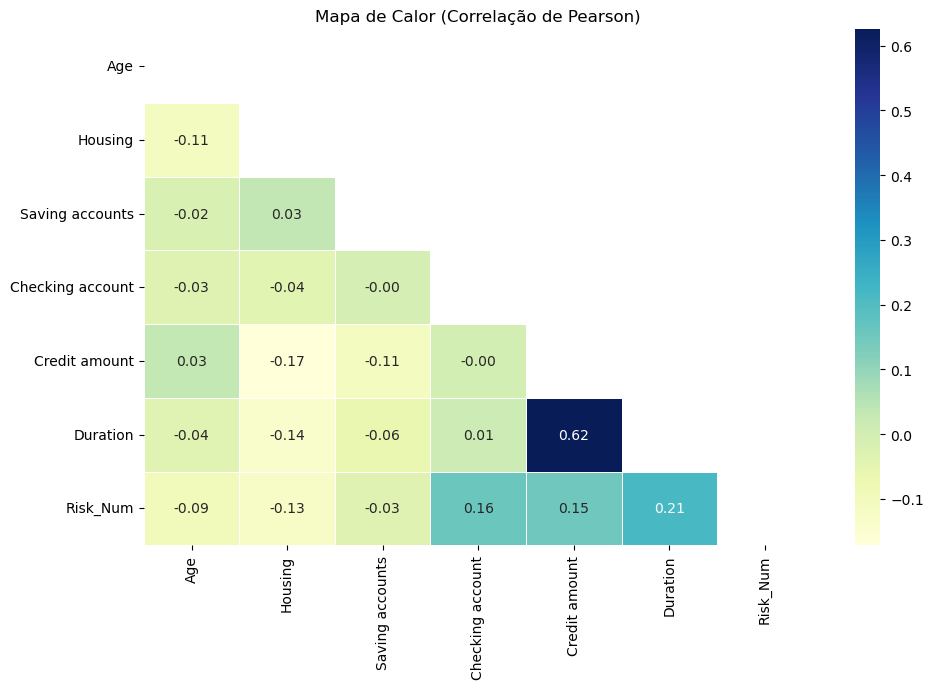

In [161]:
df_heatmap = df.copy()
def SC_LabelEncoder(x):
    val = str(x).lower()
    if "little" in val: return 1
    elif "moderate" in val: return 2
    elif "quite rich" in val: return 3
    elif "rich" in val: return 4
    else: return 0

def H_LabelEncoder(x):
    val = str(x).lower()
    if "free" in val: return 0
    elif "rent" in val: return 1
    elif "own" in val: return 2
    else: return 0

df_heatmap["Saving accounts"] = df_heatmap["Saving accounts"].apply(SC_LabelEncoder)
df_heatmap["Checking account"] = df_heatmap["Checking account"].apply(SC_LabelEncoder)
df_heatmap["Housing"] = df_heatmap["Housing"].apply(H_LabelEncoder)

df_heatmap['Risk_Num'] = df_heatmap['Risk'].map({'good': 0, 'bad': 1})

cols = ['Age', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Risk_Num']
corr = df_heatmap[cols].corr()

plt.figure(figsize=(10,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="YlGnBu", linewidths=.5, fmt=".2f")
plt.title("Mapa de Calor (Correlação de Pearson)")
plt.tight_layout()
plt.show()

- Duração e valor do crédito têm a correlação mais alta da base ($0{,}62$).
- Prazos longos ($0{,}21$), conta corrente com saldo baixo ($0{,}16$) e montantes elevados ($0{,}15$) aumentam a chance de calote.
- Moradia própria ($-0{,}13$) e maior idade ($-0{,}09$) reduzem o risco de inadimplência.
- Baixas correlações lineares gerais apontam relações não lineares, justificando o uso de modelos baseados em árvores 